In [5]:
!pip install -q tensorflow==2.18.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 100.8 MB/s eta 0:00:00


In [6]:
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import tensorflow as tf

import numpy as np
import seaborn as sns
import pandas as pd

In [7]:
tf.__version__

'2.18.0'

In [8]:
%load_ext tensorboard

In [9]:
logdir='log'

In [10]:
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

train_images, test_images = train_images / 255.0, test_images / 255.0

classes = [0,1,2,3,4,5,6,7,8,9]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
model = models.Sequential()
model.add(layers.Input((28, 28, 1)))
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

In [15]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(logdir, histogram_freq=1)

In [16]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x=train_images,
          y=train_labels,
          epochs=5,
          validation_data=(test_images, test_labels))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 31ms/step - accuracy: 0.8986 - loss: 0.3343 - val_accuracy: 0.9843 - val_loss: 0.0470
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9851 - loss: 0.0488 - val_accuracy: 0.9880 - val_loss: 0.0364
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 114s 48ms/step - accuracy: 0.9898 - loss: 0.0325 - val_accuracy: 0.9913 - val_loss: 0.0257
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 150s 52ms/step - accuracy: 0.9917 - loss: 0.0257 - val_accuracy: 0.9906 - val_loss: 0.0310
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 110s 35ms/step - accuracy: 0.9937 - loss: 0.0191 - val_accuracy: 0.9917 - val_loss: 0.0257


In [33]:
y_true=test_labels
y_pred=np.argmax(model.predict(test_images), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [34]:
classes=[0,1,2,3,4,5,6,7,8,9]

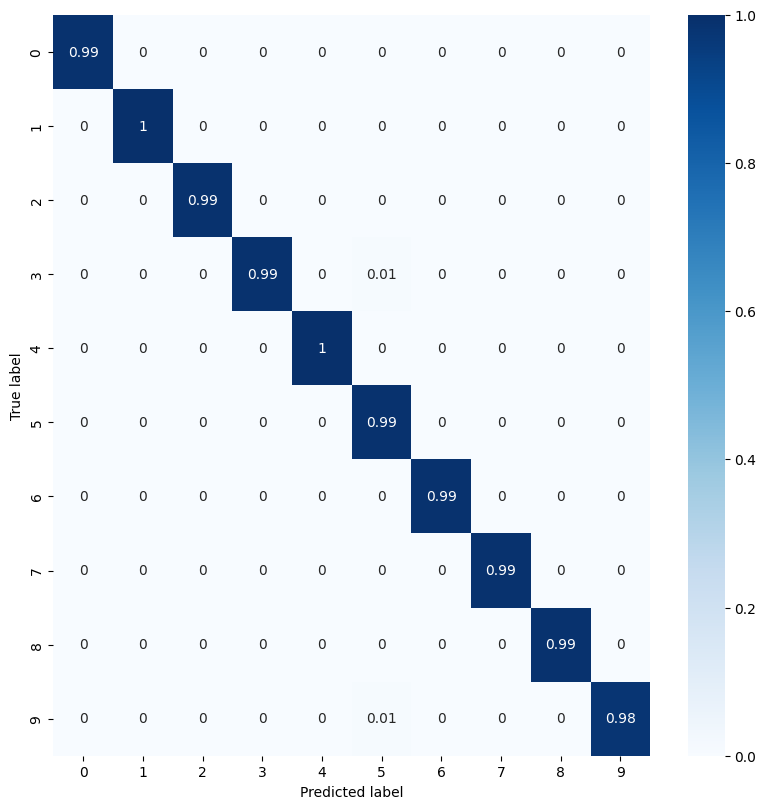

In [35]:
con_mat = tf.math.confusion_matrix(labels=y_true, predictions=y_pred).numpy()
con_mat_norm = np.around(con_mat.astype('float') / con_mat.sum(axis=1)[:, np.newaxis], decimals=2)

con_mat_df = pd.DataFrame(con_mat_norm,
                          index = classes,
                          columns = classes)

figure = plt.figure(figsize=(8, 8))
sns.heatmap(con_mat_df, annot=True, cmap=plt.cm.Blues)
plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

Para 0:
	Sensibilidade: 0.9928644240570846
	Especificidade: 0.9993347377758066
	Acurácia: 0.9987
	Precisão: 0.9938775510204082
	F-Score: 0.9933707292197859

Para 1:
	Sensibilidade: 0.9938434476693052
	Especificidade: 0.9994358569333183
	Acurácia: 0.9988
	Precisão: 0.9955947136563876
	F-Score: 0.9947183098591549

Para 2:
	Sensibilidade: 0.9922630560928434
	Especificidade: 0.9993308052643319
	Acurácia: 0.9986
	Precisão: 0.9941860465116279
	F-Score: 0.9932236205227493

Para 3:
	Sensibilidade: 0.9960199004975124
	Especificidade: 0.9989994441356309
	Acurácia: 0.9987
	Precisão: 0.9910891089108911
	F-Score: 0.9935483870967742

Para 4:
	Sensibilidade: 0.9908906882591093
	Especificidade: 0.9996671105193076
	Acurácia: 0.9988
	Precisão: 0.9969450101832994
	F-Score: 0.9939086294416244

Para 5:
	Sensibilidade: 0.980110497237569
	Especificidade: 0.999450247388675
	Acurácia: 0.9977
	Precisão: 0.9943946188340808
	F-Score: 0.9872008903728436

Para 6:
	Sensibilidade: 0.9844236760124611
	Especificidade: 

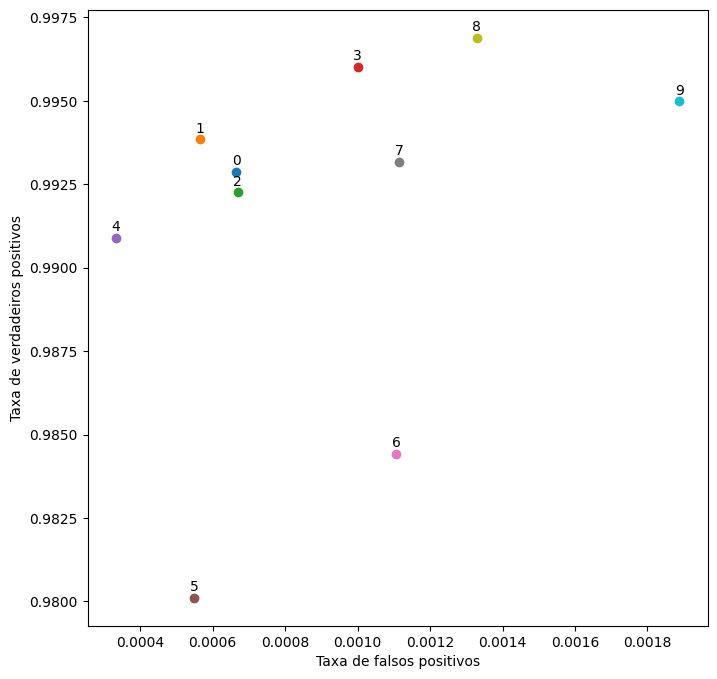

In [115]:
figure = plt.figure(figsize=(8, 8))

length = len(classes)
for i in range(length):
  con_mat_without_i_line = np.delete(con_mat, i, axis=0)
  tp = con_mat[i][i]
  fp = np.sum(np.delete(con_mat[i], i))
  fn = np.sum(con_mat_without_i_line[:,i])
  tn = np.sum(np.delete(con_mat_without_i_line,i, axis=1))
  print(f'Para {i}:')
  rec = tp / (tp + fn)
  print(f'\tSensibilidade: {rec}')
  esp = tn / (tn + fp)
  print(f'\tEspecificidade: {esp}')
  acc = (tp + tn) / (tp + tn + fp + fn)
  print(f'\tAcurácia: {acc}')
  prs = tp / (tp + fp)
  print(f'\tPrecisão: {prs}')
  fsc = 2 * (prs * rec) / (prs + rec)
  print(f'\tF-Score: {fsc}\n')
  plt.plot(1 - esp, rec, 'o')
  plt.annotate(i, (1 - esp, rec), textcoords="offset points", xytext=(0,5), ha='center')

plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos")
plt.show()